<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 76 · Hypothesis Testing &amp; Inference</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">z-Tests 🔔</div>
  <div style="font-size:15px;color:#eef2ff;max-width:740px;line-height:1.6">When the sample is large or the outcome is yes/no, the normal distribution is the reference and the z-test is the workhorse. We build the one-sample z, the one-proportion z, and the two-proportion z from the formula, then use statsmodels' proportions_ztest on a real approval poll.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
# statsmodels = the R/SAS-style stats library (pre-installed on Colab): it computes the
# standard errors, test statistics, intervals, and post-hoc comparisons, so we write less by hand.
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep, proportion_confint
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
from scipy.stats.contingency import association   # Cramer's V in one call
IND="#4f46e5"; DEEP="#4338ca"; LIGHT="#818cf8"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(76)

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 1 · WHEN z, NOT t</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Large samples and proportions</div>
<div style="color:#4a5578;margin-top:6px">The z-test uses the normal distribution as the reference. It is the right tool when the population sigma is known, or when the sample is large enough that the sample sd is essentially sigma, and for proportions, where the variance is fixed by p itself.</div>
</div>

In [2]:
mu0=100; n=400
sample=rng.normal(101.2, 15, n)
xbar=sample.mean(); s=sample.std(ddof=1); se=s/np.sqrt(n)
z=(xbar-mu0)/se; p=2*(1-stats.norm.cdf(abs(z)))
print(f"large-sample z-test of H0: mu=100   (n={n})")
print(f"xbar={xbar:.2f}, SE={se:.3f}, z={z:.2f}, two-sided p={p:.4f}")
print(f"compare t-test p (nearly identical at this n): {stats.ttest_1samp(sample,mu0).pvalue:.4f}")

large-sample z-test of H0: mu=100   (n=400)
xbar=101.67, SE=0.728, z=2.29, two-sided p=0.0221
compare t-test p (nearly identical at this n): 0.0226


At large n the t and z tests agree to the decimal, the t distribution has essentially converged to the normal. So z is the natural default for big samples and, especially, for proportions, where the standard error is determined entirely by the proportion under H0.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 2 · THE ONE-PROPORTION z-TEST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Does a rate differ from a claimed value?</div>
<div style="color:#4a5578;margin-top:6px">For a yes/no outcome we test H0: p = p0. Under H0 the standard error is sqrt(p0(1-p0)/n), a KNOWN number, so z = (phat - p0)/SE is exactly standard normal for large n. We build it once from the formula, then confirm with statsmodels' proportions_ztest, the one-line library version.</div>
</div>

In [3]:
successes, n, p0 = 545, 1000, 0.5
phat=successes/n; se0=np.sqrt(p0*(1-p0)/n)
z=(phat-p0)/se0; p=2*(1-stats.norm.cdf(abs(z)))
print(f"by hand:      phat={phat:.3f}, SE0={se0:.4f}, z={z:.2f}, two-sided p={p:.4f}")
# the library way: prop_var=p0 tells it to use the NULL value for the standard error
z2,p2 = proportions_ztest(successes, n, value=p0, prop_var=p0)
print(f"statsmodels:  z={z2:.2f}, p={p2:.4f}  (identical)")
print(f"success-failure check: n*p0={n*p0:.0f}, n*(1-p0)={n*(1-p0):.0f} (both >= 10? OK)")

by hand:      phat=0.545, SE0=0.0158, z=2.85, two-sided p=0.0044
statsmodels:  z=2.85, p=0.0044  (identical)
success-failure check: n*p0=500, n*(1-p0)=500 (both >= 10? OK)


Note the standard error uses <strong>p0</strong> (the null value), not p&#770;, because we compute everything in the world where H0 is true. A 54.5% result in 1,000 trials is about 2.8 SEs from 50%, easily significant. Once you understand the formula, <code>proportions_ztest</code> is the practical tool.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 3 · THE TWO-PROPORTION z-TEST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Comparing two groups' rates</div>
<div style="color:#4a5578;margin-top:6px">To compare two proportions we test H0: pA = pB. Under that null the best estimate of the common rate is the POOLED proportion, and the SE uses it. Again we show the formula once, then the one-line statsmodels call.</div>
</div>

In [4]:
sA,nA = 120, 800; sB,nB = 160, 820
pA,pB = sA/nA, sB/nB; pool=(sA+sB)/(nA+nB)
se=np.sqrt(pool*(1-pool)*(1/nA+1/nB))
z=(pB-pA)/se; p=2*(1-stats.norm.cdf(abs(z)))
print(f"by hand:      pA={pA:.3f}, pB={pB:.3f}, pooled={pool:.3f}, z={z:.2f}, p={p:.4f}")
# the library way: pass the two counts and the two sample sizes
z2,p2 = proportions_ztest([sB, sA], [nB, nA])
print(f"statsmodels:  z={z2:.2f}, p={p2:.4f}  (identical, pooled SE by default)")

by hand:      pA=0.150, pB=0.195, pooled=0.173, z=2.40, p=0.0163
statsmodels:  z=2.40, p=0.0163  (identical, pooled SE by default)


The pooled standard error is the signature of the two-proportion test: under H0 both groups share one rate, so we estimate it from the combined data. This is the engine behind comparing conversion rates, approval by subgroup, and pass rates between sites, and <code>proportions_ztest</code> handles it in a line.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">REAL-WORLD EXAMPLE · APPROVAL POLL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Does approval beat 60%, and does it differ by age?</div>
<div style="color:#4a5578;margin-top:6px"></div>
</div>

A poll of 820 respondents (`ch76_approval_poll.xlsx`) records whether each approves of a policy. The campaign claims approval is above 60%. We explore first, then use statsmodels for a one-proportion z-test of the claim and a two-proportion z-test comparing the youngest and oldest age bands.

In [5]:
try:    poll = pd.read_excel("../../data/ch76_approval_poll.xlsx", sheet_name="Poll")
except FileNotFoundError: poll = pd.read_excel(BASE+"ch76_approval_poll.xlsx", sheet_name="Poll")
# EXPLORE FIRST: size, missing, overall rate, and approval by age band
print("shape:", poll.shape, "| missing:", poll.isna().sum().sum())
print(f"overall approval = {poll.approve.mean():.1%}")
print(poll.groupby("age_group").approve.agg(["size","mean"]).round(3))

shape: (820, 5) | missing: 0
overall approval = 64.3%
           size   mean
age_group             
18-34       270  0.707
35-54       328  0.640
55+         222  0.568


approval 64.3% vs claim 60%: z=2.49, two-sided p=0.0126 -> reject H0 (higher)
Cohen h vs 60% = +0.09  (proportion effect size; |0.2| small, |0.5| medium, |0.8| large)
young 70.7% (n=270) vs old 56.8% (n=222): z=3.22, p=0.0013 -> reject H0 (differ by age)


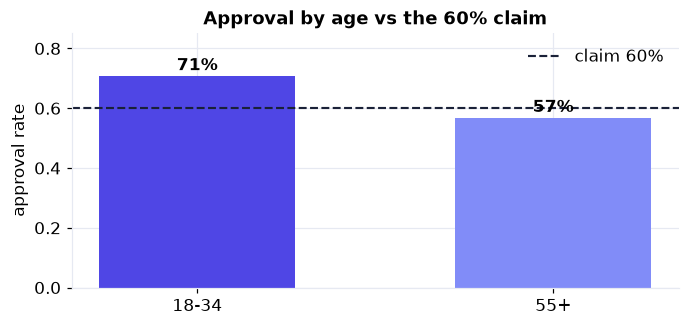

In [6]:
# one-proportion z-test of H0: p = 0.60 (library, null value for the SE)
a=poll.approve
z,p = proportions_ztest(a.sum(), len(a), value=0.60, prop_var=0.60)
print(f"approval {a.mean():.1%} vs claim 60%: z={z:.2f}, two-sided p={p:.4f}",
      "-> reject H0 (higher)" if p<0.05 else "-> fail to reject")
phi = lambda pp: 2*np.arcsin(np.sqrt(pp))
print(f"Cohen h vs 60% = {phi(a.mean())-phi(0.60):+.2f}  (proportion effect size; |0.2| small, |0.5| medium, |0.8| large)")
# two-proportion z-test: youngest vs oldest band
y=poll[poll.age_group=="18-34"].approve; o=poll[poll.age_group=="55+"].approve
z2,p2 = proportions_ztest([y.sum(), o.sum()], [len(y), len(o)])
print(f"young {y.mean():.1%} (n={len(y)}) vs old {o.mean():.1%} (n={len(o)}): z={z2:.2f}, p={p2:.4f}",
      "-> reject H0 (differ by age)" if p2<0.05 else "-> fail to reject")
fig,ax=plt.subplots(figsize=(6.4,3.1))
ax.bar(["18-34","55+"],[y.mean(),o.mean()],color=[IND,LIGHT],width=0.55)
ax.axhline(0.60,color=INK,ls="--",lw=1.4,label="claim 60%")
ax.set_ylim(0,0.85); ax.set_ylabel("approval rate"); ax.set_title("Approval by age vs the 60% claim"); ax.legend()
for i,v in enumerate([y.mean(),o.mean()]): ax.text(i,v+0.02,f"{v:.0%}",ha="center",fontweight="bold")
plt.tight_layout(); plt.show()

Overall approval is about <strong>64.3%</strong>, and the one-proportion z-test (z &#8776; 2.49, p &#8776; 0.013) rejects the 60% claim: approval is genuinely higher. The age gap is sharper still, the youngest band (70.7%) versus the oldest (56.8%) gives z &#8776; 3.22, p &#8776; 0.001, a clear, real difference. Large n plus the success-failure condition make the normal approximation trustworthy here.

<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ z-tests</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">The z-test uses the normal as its reference: right for large-sample means and for proportions, where the null fixes the variance. The one-proportion test uses SE from p0; the two-proportion test uses a POOLED rate, both available in one line from statsmodels&#39; proportions_ztest. On real poll data, approval beats 60% (z=2.49, p=0.013) and differs by age (z=3.22, p=0.001). When sigma is unknown and n is small, the t-test, next chapter, is the honest choice.</div></div>

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>